# CAPSTONE PROJECT: Analysis of NHANES Body Measurement Data

This project analyzes body measurements of adult males and females using NumPy and Matplotlib. The goal is to compare distributions, compute statistical measures, and explore relationships between variables such as weight, height, BMI, and body ratios.

The dataset is sourced from NHANES and includes measurements like weight, height, arm length, and circumferences.

## Data Loading

In this step, we load the male and female datasets into NumPy arrays for further analysis.

In [21]:
import numpy as np

male = np.genfromtxt(r'C:\Users\Ayush Yadav\OneDrive\Desktop\nhanes_adult_male_bmx_2020.csv', delimiter=',', skip_header=1)
female = np.genfromtxt(r'C:\Users\Ayush Yadav\OneDrive\Desktop\nhanes_adult_female_bmx_2020.csv', delimiter=',', skip_header=1)

In [22]:
male = male[~np.isnan(male).any(axis=1)]
female = female[~np.isnan(female).any(axis=1)]


Both datasets have been successfully loaded as NumPy arrays with 7 columns representing different body measurements.

## Histogram of Weights

This section visualizes the distribution of weights for males and females using histograms.

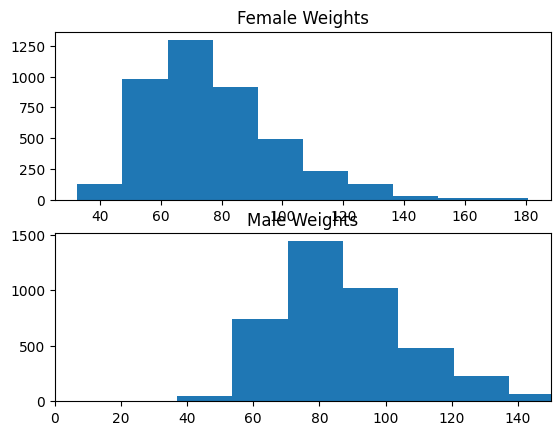

In [23]:
import matplotlib.pyplot as plt

female_weights = female[:, 0]
male_weights = male[:, 0]

plt.subplot(2,1,1)
plt.hist(female_weights)
plt.title("Female Weights")

plt.subplot(2,1,2)
plt.hist(male_weights)
plt.title("Male Weights")

plt.xlim(0,150)

plt.show()

The histograms show that male weights tend to be higher and more spread out compared to female weights.

## Boxplot Comparison

This plot compares male and female weight distributions using boxplots.

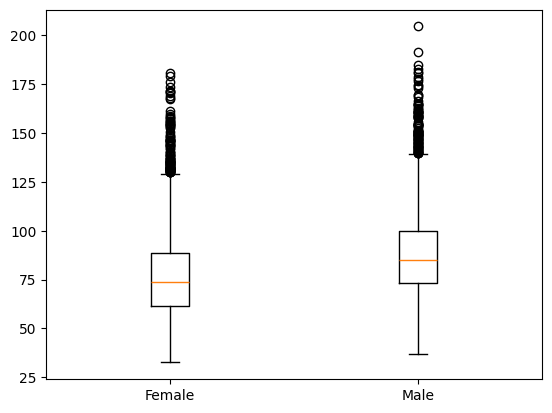

In [24]:
plt.boxplot([female_weights, male_weights])
plt.xticks([1,2], ['Female', 'Male'])
plt.show()

The boxplot indicates that males generally have a higher median weight and slightly greater variability than females.

## Statistical Analysis

We compute mean, standard deviation, and median for both groups.

In [25]:
print("Female Mean:", np.mean(female_weights))
print("Male Mean:", np.mean(male_weights))

print("Female Std:", np.std(female_weights))
print("Male Std:", np.std(male_weights))

print("Female Median:", np.median(female_weights))
print("Male Median:", np.median(male_weights))

Female Mean: 77.40379057095475
Male Mean: 88.36454300416565
Female Std: 21.54250829019315
Male Std: 21.418936717962495
Female Median: 73.6
Male Median: 85.0


The results show that male weights have higher mean and dispersion. This indicates that male weights vary more compared to female weights.

## BMI Calculation

BMI is calculated using weight and height.

In [26]:
female_height = female[:,1]

bmi_female = female_weights / ((female_height/100)**2)

female = np.column_stack((female, bmi_female))

A new column for BMI has been successfully added to the female dataset.

## Standardization (Z-score)

Standardization is performed to normalize the data.

In [27]:
zfemale = (female - np.mean(female, axis=0)) / np.std(female, axis=0)

The dataset is now standardized with mean 0 and standard deviation 1.

## Correlation Analysis

We compute Pearson and Spearman correlations.

import pandas as pd

cols = [1,0,6,5,7]  # height, weight, waist, hip, BMI
df = pd.DataFrame(zfemale[:, cols], columns=['Height','Weight','Waist','Hip','BMI'])

print(df.corr(method='pearson'))
print(df.corr(method='spearman'))

Strong positive correlations are observed between weight and BMI, and between waist and hip circumference.

## Ratio Calculation

We compute waist-to-height and waist-to-hip ratios.

In [28]:
male_ratio1 = male[:,6] / male[:,1]
male_ratio2 = male[:,6] / male[:,5]

female_ratio1 = female[:,6] / female[:,1]
female_ratio2 = female[:,6] / female[:,5]

male = np.column_stack((male, male_ratio1, male_ratio2))
female = np.column_stack((female, female_ratio1, female_ratio2))

New ratio columns have been added to both datasets.

## Ratio Comparison

This plot compares ratios between genders.

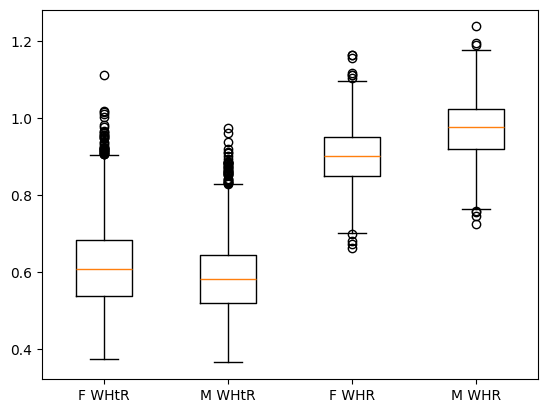

In [29]:
plt.boxplot([female_ratio1, male_ratio1, female_ratio2, male_ratio2])
plt.xticks([1,2,3,4], ['F WHtR','M WHtR','F WHR','M WHR'])
plt.show()

The plot shows differences in fat distribution between males and females.

## Comparison of BMI and Ratios

BMI is simple but does not show fat distribution. Waist ratios provide better insight into health risks but require more measurements.

## Extreme BMI Cases

We analyze individuals with lowest and highest BMI.

In [30]:
bmi_sorted = np.argsort(female[:,7])

lowest = zfemale[bmi_sorted[:5]]
highest = zfemale[bmi_sorted[-5:]]

print("Lowest BMI:\n", lowest)
print("Highest BMI:\n", highest)

Lowest BMI:
 [[-2.07978523 -1.22299143 -1.5478402  -1.16905675 -2.1947611  -2.0405496
  -1.94212128 -2.05024028]
 [-1.88017988 -0.18929313 -1.71835247  0.38637892 -2.4443617  -1.85491922
  -2.05708015 -1.99487987]
 [-1.53667299  1.80730222  0.62619127  0.5730312  -2.26607556 -1.6756899
  -1.7064556  -1.97088383]
 [-1.843044   -0.26009438 -0.22637009  0.51081377 -2.30173278 -2.25178417
  -1.85590213 -1.94177591]
 [-1.61094475  0.88688592 -0.09848588  0.47970506 -2.21258971 -1.82931504
  -1.71220354 -1.89319577]]
Highest BMI:
 [[ 4.2472403   0.29215539  1.86240524 -0.98240447  2.3693641   4.10445598
   3.81731803  4.39649161]
 [ 4.45612963  0.50455915  1.69189297 -1.13794804  3.34993787  3.98283607
   2.90339503  4.46201122]
 [ 4.34936397  0.27799514  2.84285081  1.94181459  4.36616887  3.9188256
   3.75409065  4.51466896]
 [ 4.8042785   0.88688592  2.11817365  1.81737973  3.77782461  4.02124236
   4.08172343  4.54270932]
 [ 4.36328993 -0.03353037 -0.05585782 -0.17357792  2.77942222  4.3

The lowest BMI individuals are likely underweight, while highest BMI individuals indicate overweight or obesity. Their standardized values show how extreme they are compared to the population.

## Conclusion

This analysis shows clear differences between male and female body measurements. Males generally have higher weight and dispersion. BMI and body ratios provide useful but different insights into health and body composition.